In [102]:
import h5py
from sipyco import pyon
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import os as os
import sys

sys.path.append(
    "/home/ae19663/artiq"
)  # Adjust this path to the parent directory of 'repository'
from repository.imaging.processor import AbsImage  # noqa: E402


# it will take folder(scan path) path as input and return sorted list of h5 files DIRECTORY
# the files are sorted based on the numeric part of their names, which is before the first hyphen '-'.
# For example, if the files are named like "000001234-AbsorptionImageExpFrag.h5",
# the sorting will be based on the numeric part "000001234".


folder_directory = (
    "../results/2025-10-16/17/"  # Example directory path, adjust as needed
)
file_names = os.listdir(folder_directory)

# this will print the file names in the directory
print(f"Files in directory: {file_names}")


# Enter the name of the file you want to analyze, this file consisit of many runs of of particular scan parameter if you have multiple runs
particular_directory = (
    folder_directory + "000014602-TrapFrequencyExpFrag.h5"
)  # Example file path, adjust as needed


class EXTRACTOR():
    def __init__(self, artiq_folder_directory, folder_directory, particular_directory):
        self.artiq_folder_directory = artiq_folder_directory
        self.folder_directory = folder_directory
        self.particular_directory = particular_directory
        self.files_directory = EXTRACTOR.sorted_files(folder_directory)

    def list_h5_files(self):
        """
        List all .h5 files in the artiq folder directory.
        """
        file_names = os.listdir(self.folder_directory)
        # calculate how many files are there in the directory
        num_files = len(file_names)
        print(f"Number of files in the directory: {num_files}")
        return [f for f in file_names if f.endswith(".h5")], num_files

    def sorted_files(directory):
        """
        Sort files in the given directory based on the numeric part of their names.
        """
        files = os.listdir(directory)
        file_num = []
        file_name = []

        for i in files:
            # Split the file name into two parts and sort by the numeric part
            file_num.append(i.split("-")[0])
            file_name.append(i.split("-")[1])

        # Sort the files based on the numeric part
        file_num, file_name = zip(*sorted(zip(file_num, file_name)))

        # Recombine the file number and file name into a single list
        sorted_files_list = [f"{num}-{name}" for num, name in zip(file_num, file_name)]

        # Directory list for the files using the sorted file names
        files_directory = [
            os.path.join(directory, f) for f in sorted_files_list if f.endswith(".h5")
        ]

        # Example usage:
        # directory = "../results/2025-07-08/21/"
        # files_directory = sorted_files(directory)

        return files_directory

    def get_override_args(file_directory, hide_defaults=True):
        vals = {}

        f1 = h5py.File(file_directory, "r")
        args = pyon.decode(f1["expid"][()])["arguments"]
        for k, v in args.items():
            if k == "ndscan_params":
                params = pyon.decode(args["ndscan_params"])
                overrides = params["overrides"]
                for k, v in overrides.items():
                    spec = params["schemata"][k]["spec"]
                    val = v[0]["value"]
                    default = type(val)(params["schemata"][k]["default"])
                    if hide_defaults and val == default:
                        continue
                    vals[k] = [val / spec.get("scale", 1), spec.get("unit", "")]
            else:
                vals[k] = [v, ""]
        return vals

    vals = get_override_args(particular_directory, hide_defaults=False)

    def args_names_and_vals(vals):
        # Print arguments names and their values
        args_names = []
        args_vals = []
        for k, (v, unit) in vals.items():
            # print(f"{k} = {v} {unit}")
            args_names.append(k)
            args_vals.append(v)
        return args_names, args_vals

    files_directory = sorted_files(folder_directory)
    # print(files_directory)

    matching_args = []
    for i in range(len(files_directory)):
        #print(f"File {i + 1}: {files_directory[i]}")
        vals1 = get_override_args(files_directory[i])
        args_name1, args_val1 = args_names_and_vals(vals1)
        for j in range(len(files_directory)):
            vals2 = get_override_args(files_directory[j])
            args_name2, args_val2 = args_names_and_vals(vals2)
            if args_name1 == args_name2:
                # print(f"Matching arguments found for {files_directory[i]} and {files_directory[j]}")
                matching_args.append((files_directory[i], files_directory[j]))
            else:
                # print(f"No matching arguments for {files_directory[i]} and {files_directory[j]}")
                pass

    # plot the absorption image of the particular run in the scan, it is still a work in progress not working properly
    def plot_absorption_image(file_directory, run_number):
        f1 = h5py.File(file_directory, "r")
        if run_number == 0:
            a = 0
        else:
            a = run_number * 3
        image_0 = "Images.All" + "." + str(a)
        image_1 = "Images.All" + "." + str(a + 1)
        image_2 = "Images.All" + "." + str(a + 2)

        absimg = AbsImage(
            data=f1["datasets"][image_0][()],
            ref=f1["datasets"][image_1][()],
            bg=f1["datasets"][image_2][()],
            magnification=0.25,  # Set default magnification
        )
        absimg.plot()
        #plt.show()

    scan_number = 5  # Example scan number, adjust as needed

    #plot_absorption_image(particular_directory, scan_number)
    # Extracting the values and the units from the files
    f1 = h5py.File(files_directory[0], "r")
    a = f1["datasets"]

    # Extracting the values and the units from the files
    f1 = h5py.File(files_directory[0], "r")
    a = f1["datasets"]
    #print(f"Keys in the datasets: {list(a.keys())}")

file_number=2

class Extractor_file(EXTRACTOR):
    def __init__(self, file_number):
        self.particular_directory = particular_directory
        self.file_number = file_number

        if self.file_number < 0 or self.file_number >= len(self.files_directory):
            raise ValueError(
                f"File number {self.file_number} is out of range. Please choose a number between 0 and {len(self.files_directory) - 1}."
            )

        # Extracting the values and the units from the files
        f1 = h5py.File(self.files_directory[self.file_number], "r")
        # extract file name and run number from the file path

        file_name = os.path.basename(self.files_directory[self.file_number])
        run_number = int(file_name.split("-")[0])
        c = "ndscan.rid_" + str(run_number) + ".points.channel_info"
        d = "ndscan.rid_" + str(run_number) + ".points.axis_0"

        import re  # Ensure re is imported

        a = f1["datasets"][c][()]

        peakx = []
        peaky = []
        centroidx = []
        centroidy = []
        wavelength = []
        atom_number = []
        A = []
        sx = []
        sy = []
        x0 = []
        y0 = []

        for i in range(a.shape[0]):
            # decode if bytes, otherwise use as is
            if isinstance(a[i], bytes):
                decoded = a[i].decode("utf-8")
                lines = decoded.split("\n")
            else:
                lines = a[i]

            for line in lines:
                b = line.strip(",").split(":")
                key = b[0].strip().strip('"')
                if key == "wavelength":
                    wavelength.append(float(b[1]))
                elif key == "atom_number":
                    atom_number.append(float(b[1]))
                elif key == "peak_pixel":  # Assuming this is a key for peak pixels
                    # extract numbers from tuple string
                    tuple_str = ":".join(b[1:]).strip()
                    nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
                    if len(nums) >= 3:
                        peakx.append(float(nums[0]))
                        peaky.append(float(nums[1]))
                        # If you want the third value, use float(nums[2])
                    # else skip or handle error
                elif key == "centroid_pixel":  # Assuming this is a key for centroid pixels
                    tuple_str = ":".join(b[1:]).strip()
                    nums = re.findall(r"[-+]?\d*\.\d+|\d+", tuple_str)
                    if len(nums) >= 3:
                        centroidx.append(float(nums[0]))
                        centroidy.append(float(nums[1]))
                        # If you want the third value, use float(nums[2])
                elif key == "best_values_pixel":  # Assuming this is a key for some values
                    # Extract dictionary from line
                    match = re.search(r"\{(.+?)\}", line)
                    if match:
                        dict_str = match.group(1)
                        items = dict_str.split(",")
                        for item in items:
                            item = item.strip()
                            if ":" in item:
                                key_part, value_part = item.split(":", 1)
                                key_item = key_part.strip().strip("'")
                                value_str = value_part.strip()
                                # Convert to float or int
                                if "." in value_str or "e" in value_str:
                                    value = float(value_str)
                                else:
                                    value = int(value_str)
                                # Append to the correct list
                                if key_item == "A":
                                    A.append(value)
                                elif key_item == "x0":
                                    x0.append(value)
                                elif key_item == "y0":
                                    y0.append(value)
                                elif key_item == "sx":
                                    sx.append(value)
                                elif key_item == "sy":
                                    sy.append(value)
                                elif key_item == "theta":
                                    if not hasattr(self, "theta"):
                                        self.theta = []
                                    self.theta.append(value)
                                elif key_item == "z0":
                                    if not hasattr(self, "z0"):
                                        self.z0 = []
                                    self.z0.append(value)

        # extract scan parameters from the file
        scan_params = f1["datasets"][d][()]
        # add more decimal places to scan params

        #print(scan_params)

        # list contents in datasets
        datasets = list(f1["datasets"].keys())
        #print("Datasets in the file:", datasets)

        # print the extracted values
        #print("Wavelength:", wavelength)
        #print("Atom Number:", atom_number)
        #print("Peak X:", peakx)
        #print("Peak Y:", peaky)
        #print("Centroid X:", centroidx)
        #print("Centroid Y:", centroidy)
        #print("A:", A)
        #print("Sx:", sx)
        #print("Sy:", sy)
        #print("X0:", x0)
        #print("Y0:", y0)

        # store everything in the csv file also scan parameters
        self.data = {
            "wavelength": wavelength,
            "atom_number": atom_number,
            "peakx": peakx,
            "peaky": peaky,
            "centroidx": centroidx,
            "centroidy": centroidy,
            "A": A,
            "sx": sx,
            "sy": sy,
            "x0": x0,
            "y0": y0,
            "scan_params": scan_params,
        }

        self.datasets = datasets

Files in directory: ['000014605-TrapFrequencyExpFrag.h5', '000014604-TrapFrequencyExpFrag.h5', '000014603-TrapFrequencyExpFrag.h5', '000014602-TrapFrequencyExpFrag.h5']


Data extraction complete.
[[74.02102861 54.61109701 48.23239925 49.704433   61.90513911 68.5823705
  67.66045918 91.5483482  85.47566365 82.59845367 84.25712668 72.7620742
  67.78563928 61.03583549 65.91536109 62.68021771 63.80150233 72.23918684
  73.11278092 88.75487384 77.60536433 75.7823468  72.29772399 77.10912803
  84.40837061 75.10118763 64.30894205 61.49334009 84.4155493  62.34107822
  82.33541194 68.72024166 74.70861144 65.78521402 69.28389848 68.12174168
  70.41611611 85.47267083 71.40411998 82.46978747]
 [78.32725753 55.56841057 46.649284   45.26181503 50.1625615  76.27423208
  59.44568571 81.04299726 68.67016115 76.94519683 76.83150993 73.2351316
  68.21368379 70.33649973 66.75237337 70.27030061 81.99186521 78.83647145
  81.71934305 73.82777441 86.84288942 66.23459081 67.13913447 81.9780814
  77.03910324 87.88411749 69.78244089 92.56129929 70.35658182 82.96717406
  63.74655948 63.62905135 68.55396023 91.53521446 72.98482176 88.29095506
  88.12910541 89.9755566  85.89452514 7

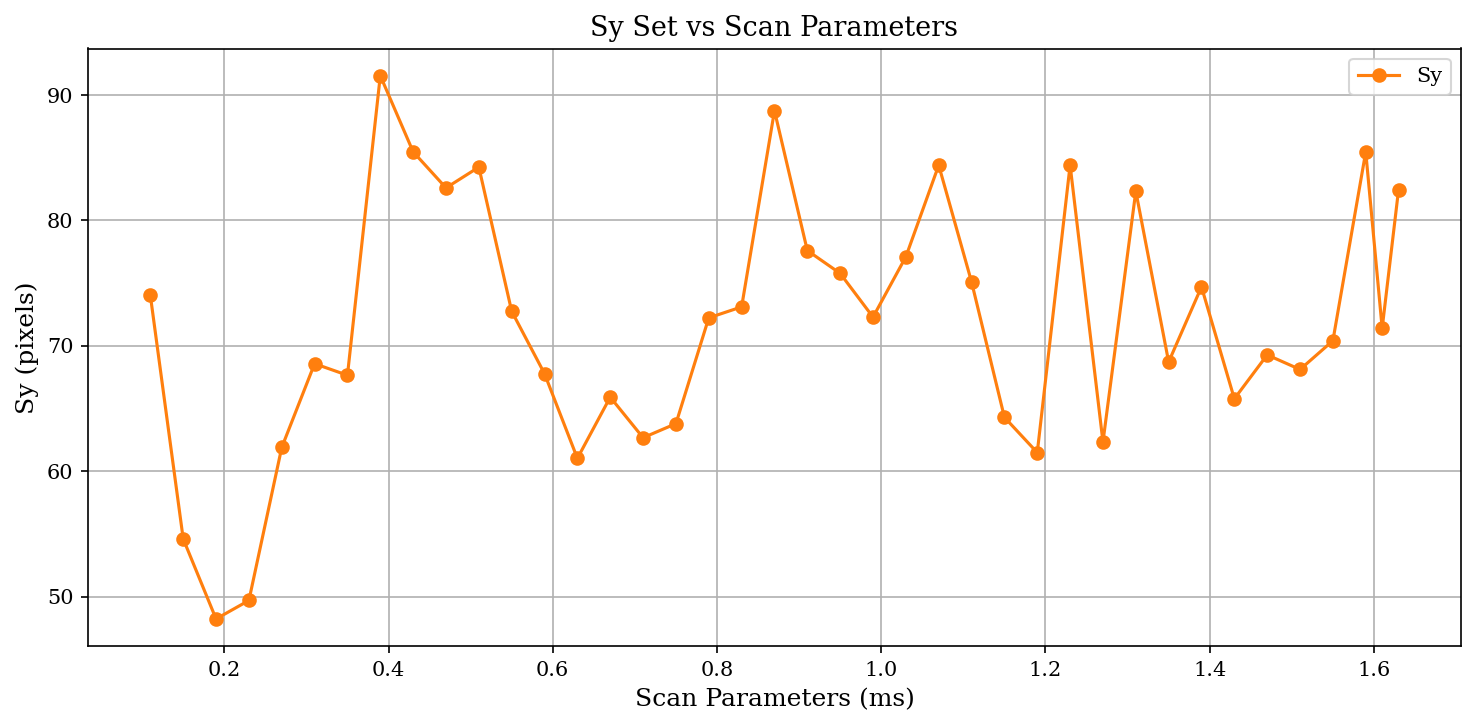

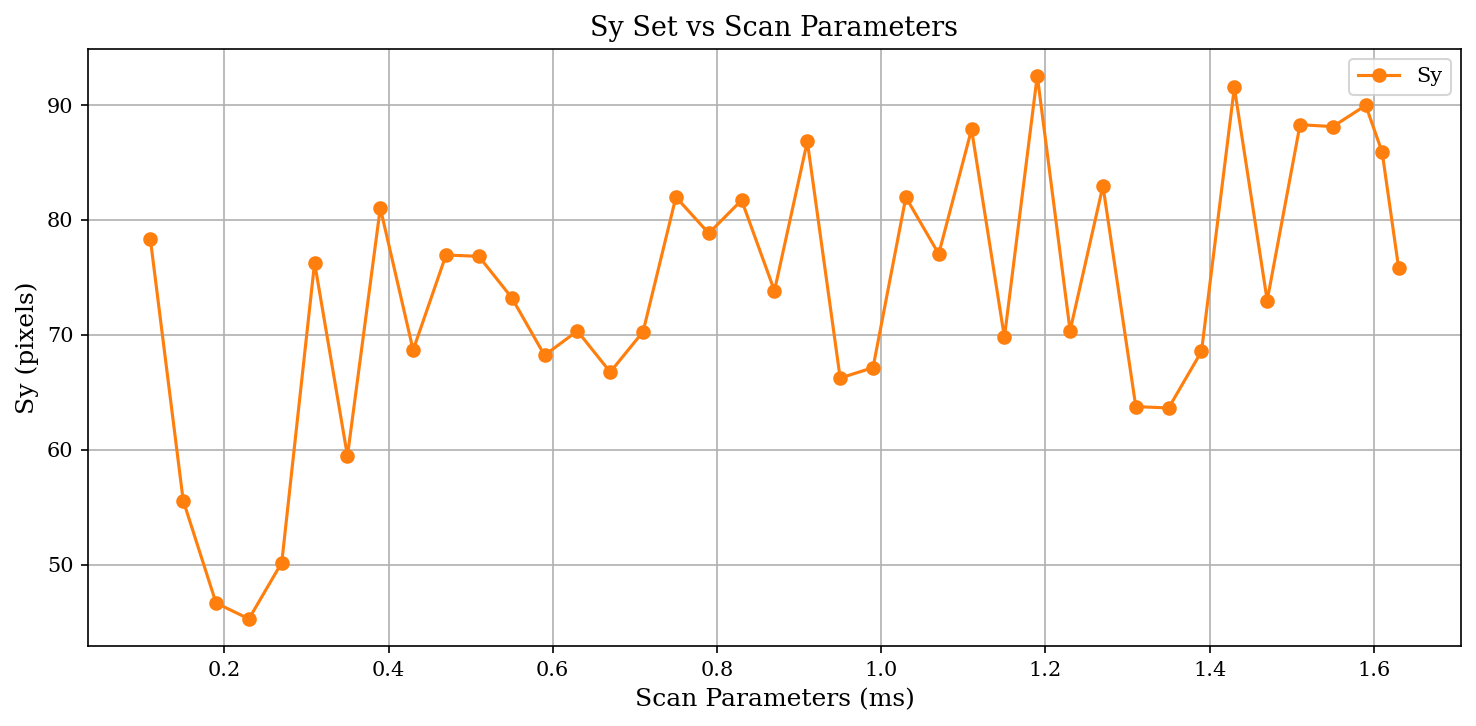

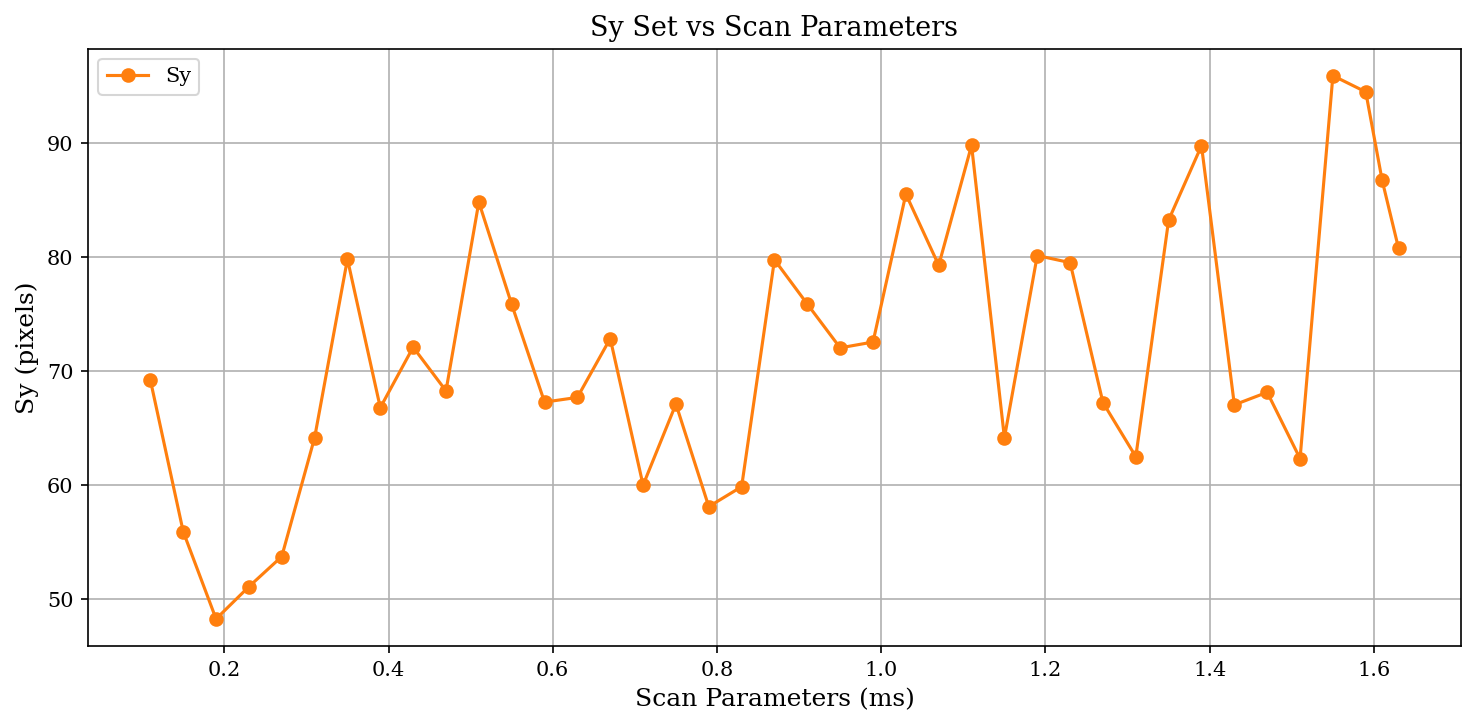

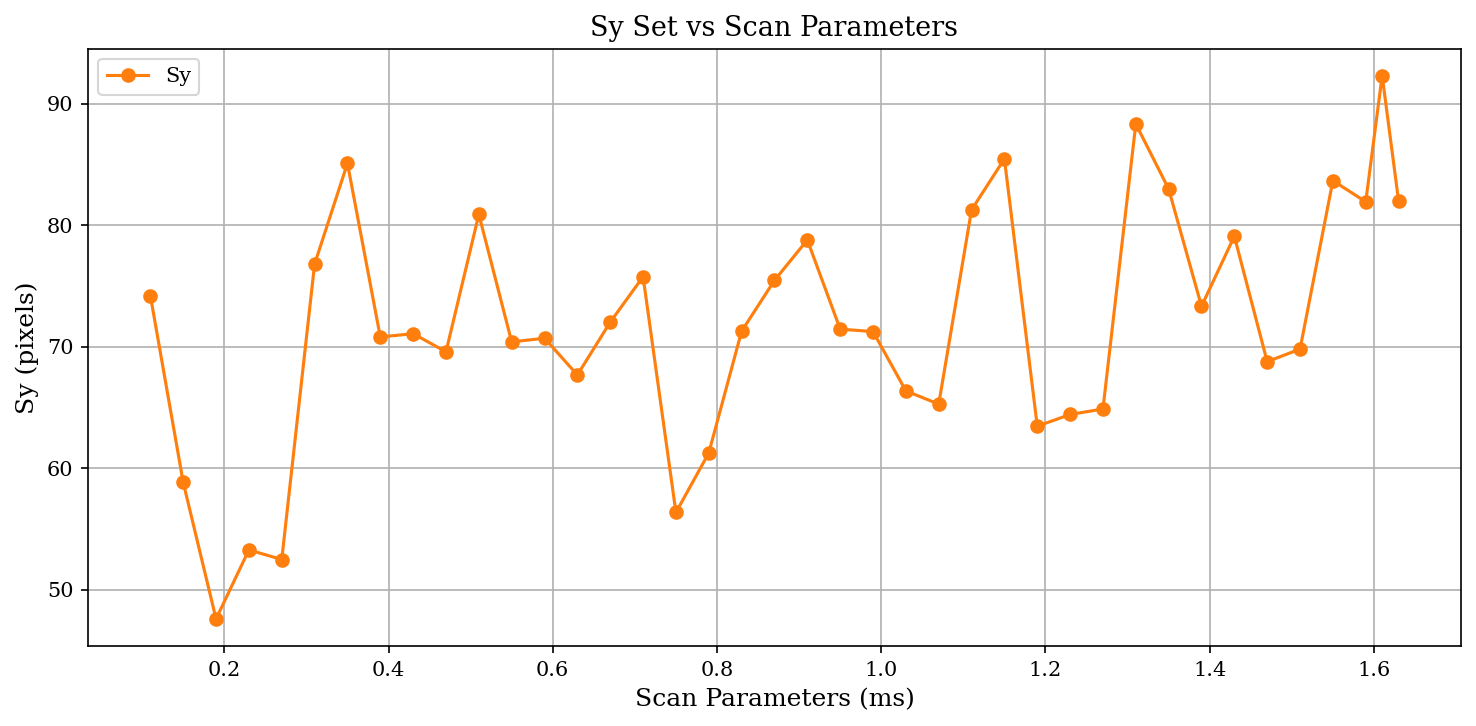

In [103]:
# exposure time
exposure_time = 0.11e-3
scaling_factor = 1.55 * 1e-6

set=3, #number of files in the set
range_1 = 0   #starting file number
range_2 = 4   #ending file number


Peak_x_set = []
Peak_y_set = []
Centroid_x_set = []
Centroid_y_set = []
A_set = []
Sx_set = []
Sy_set = []
X0_set = []
Y0_set = []
Wavelength_set = []
Atom_number_set = []
Scan_params_set = []


#go to all the files in the set see if scan parameters are same or not
# if same then extract the data and store in the lists
# if not same then print the message and stop the program	

for i in range(range_1, range_2):
	try:
		Extractor_file_instance = Extractor_file(i)
		dataset = Extractor_file_instance.data
		scan_params = dataset['scan_params']
		if scan_params.all() == Extractor_file_instance.data['scan_params'].all():
			# Extract data and store in lists
			Peak_x_set.append(dataset['peakx'])
			Peak_y_set.append(dataset['peaky'])
			Centroid_x_set.append(dataset['centroidx'])
			Centroid_y_set.append(dataset['centroidy'])
			A_set.append(dataset['A'])
			Sx_set.append(dataset['sx'])
			Sy_set.append(dataset['sy'])
			X0_set.append(dataset['x0'])
			Y0_set.append(dataset['y0'])
			Wavelength_set.append(dataset['wavelength'])
			Atom_number_set.append(dataset['atom_number'])
			Scan_params_set.append(dataset['scan_params'])
		else:
			print(f"Scan parameters do not match for file {i}. Stopping extraction.")
			break

	except KeyError as e:
		print(f"KeyError: {e}")
		print("The required dataset does not exist in the selected file. Please check the file or choose a different file_number.")


# Convert lists to numpy arrays for easier manipulation
Peak_x_set = np.array(Peak_x_set)
Peak_y_set = np.array(Peak_y_set)
Centroid_x_set = np.array(Centroid_x_set)
Centroid_y_set = np.array(Centroid_y_set)
A_set = np.array(A_set)
Sx_set = np.array(Sx_set)
Sy_set = np.array(Sy_set)
X0_set = np.array(X0_set)
Y0_set = np.array(Y0_set)
Wavelength_set = np.array(Wavelength_set)
Atom_number_set = np.array(Atom_number_set)
Scan_params_set = np.array(Scan_params_set)

print("Data extraction complete.")
#print(Scan_params_set)


for i in range(len(Scan_params_set)):
	# sort each array in increasing order and then sort all the other arrays based on the scan parameters
	sorted_indices = np.argsort(Scan_params_set[i])
	Scan_params_set[i] = Scan_params_set[i][sorted_indices]
	Peak_x_set[i] = Peak_x_set[i][sorted_indices]
	Peak_y_set[i] = Peak_y_set[i][sorted_indices]
	Centroid_x_set[i] = Centroid_x_set[i][sorted_indices]
	Centroid_y_set[i] = Centroid_y_set[i][sorted_indices]
	A_set[i] = A_set[i][sorted_indices]
	Sx_set[i] = Sx_set[i][sorted_indices]
	Sy_set[i] = Sy_set[i][sorted_indices]
	X0_set[i] = X0_set[i][sorted_indices]
	Y0_set[i] = Y0_set[i][sorted_indices]
	Wavelength_set[i] = Wavelength_set[i][sorted_indices]
	Atom_number_set[i] = Atom_number_set[i][sorted_indices]

#print(Peak_x_set)
print(Sy_set)
print(Scan_params_set)
#print(Sy_set)
# Change units of scan params in ms and add exposure time to it
for i in range(len(Scan_params_set)):
	Scan_params_set[i] = Scan_params_set[i] + exposure_time

#in 2d find means and std of each column in the 2D array
def mean_std(dataset):
	means = []
	stds = []
	for j in range(dataset.shape[1]):
		means.append(np.mean(dataset[:,j]))
		stds.append(np.std(dataset[:,j]))
	return means, stds


#save all the data in the csv file with date and timestamp and folder name and which files used in the path i will give it later

#data_dict = {
	#'Scan_params_set': Scan_params_set.flatten(),
	#'Peak_x_set': Peak_x_set.flatten(),
	#'Peak_y_set': Peak_y_set.flatten(),
	#'Centroid_x_set': Centroid_x_set.flatten(),
	#'Centroid_y_set': Centroid_y_set.flatten(),
	#'A_set': A_set.flatten(),
	#'Sx_set': Sx_set.flatten(),
	##'Sy_set': Sy_set.flatten(),
	#'X0_set': X0_set.flatten(),
	#'Y0_set': Y0_set.flatten(),
	#'Wavelength_set': Wavelength_set.flatten(),
	#'Atom_number_set': Atom_number_set.flatten()
#}

#plot the syset vs scan parameters

import matplotlib.pyplot as plt

for i in range(len(Scan_params_set)):
	Scan_params_set[i] = Scan_params_set[i] * 1e3  # convert to ms
	plt.figure(figsize=(10, 5))
	plt.plot(Scan_params_set[i], Sy_set[i], "o-", label="Sy", color="tab:orange")
	plt.xlabel("Scan Parameters (ms)")
	plt.ylabel("Sy (pixels)")
	plt.title("Sy Set vs Scan Parameters")
	plt.legend()
	plt.grid(True)
	plt.tight_layout()
	plt.show()

Original Time data: [0.00011 0.00015 0.00019 0.00023 0.00027 0.00031 0.00035 0.00039 0.00043
 0.00047 0.00051 0.00055 0.00059 0.00063 0.00067 0.00071 0.00075 0.00079
 0.00083 0.00087 0.00091 0.00095 0.00099 0.00103 0.00107 0.00111 0.00115
 0.00119 0.00123 0.00127 0.00131 0.00135 0.00139 0.00143 0.00147 0.00151
 0.00155 0.00159 0.00161 0.00163]
Original Centroid data: [1.14619792e-04 8.71721191e-05 7.39233465e-05 7.72520214e-05
 8.45981909e-05 1.10757410e-04 1.13165394e-04 1.20205224e-04
 1.15219172e-04 1.15247753e-04 1.26644761e-04 1.13255355e-04
 1.06174921e-04 1.03371732e-04 1.07558339e-04 1.04131761e-04
 1.04351689e-04 1.04805762e-04 1.10821619e-04 1.23160823e-04
 1.23664670e-04 1.10641070e-04 1.09761770e-04 1.20516153e-04
 1.18588236e-04 1.29454235e-04 1.09938344e-04 1.15352124e-04
 1.15761337e-04 1.07511301e-04 1.15056803e-04 1.15708710e-04
 1.18727372e-04 1.17594045e-04 1.08190775e-04 1.11819248e-04
 1.31033661e-04 1.36357769e-04 1.30336262e-04 1.24423645e-04]
Sorted Time data: [

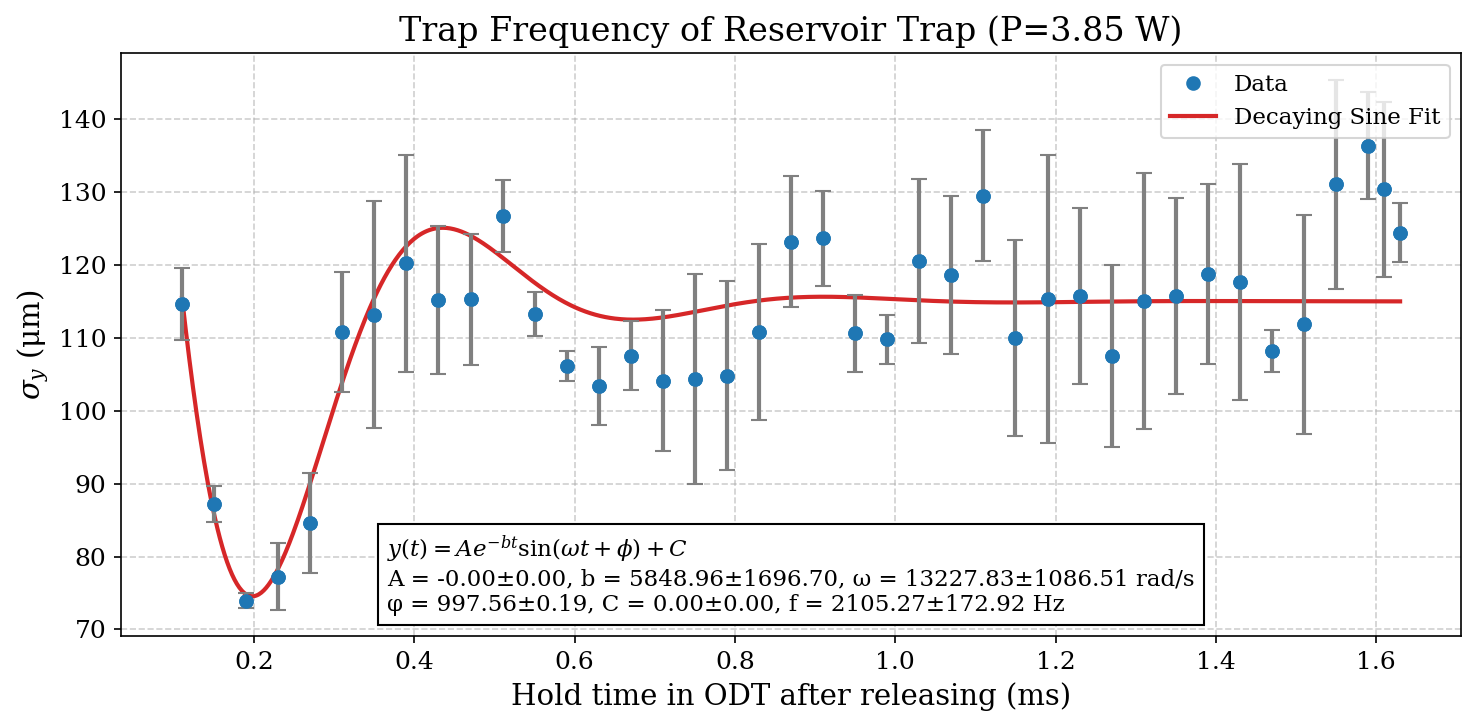

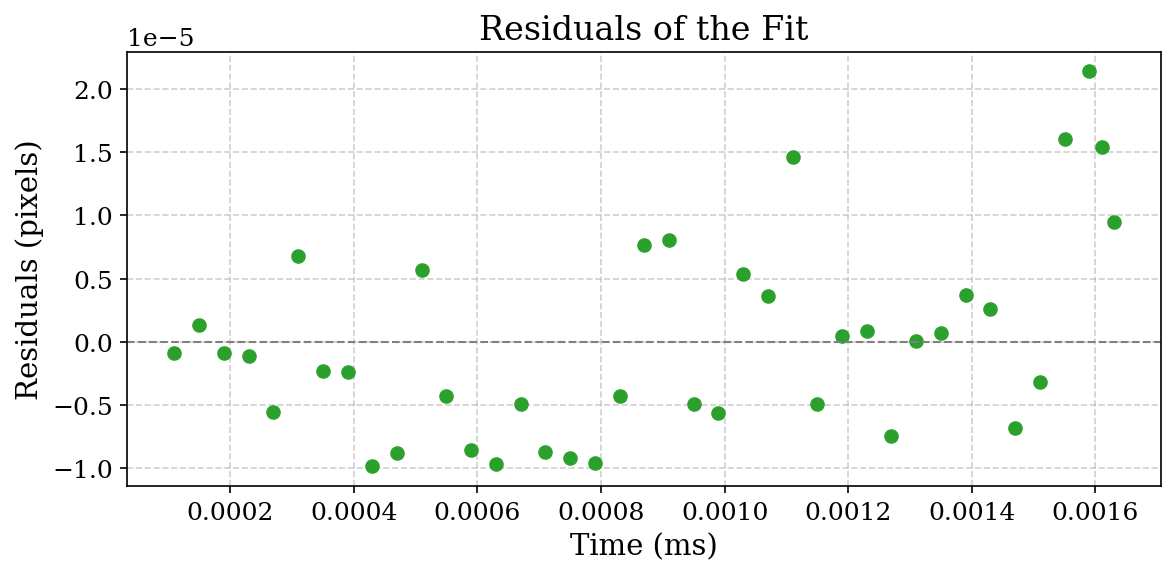

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from matplotlib.offsetbox import AnchoredText
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset
import matplotlib as mpl

# show the euation of the fit in latex
from matplotlib.offsetbox import AnchoredText



sy_mean = mean_std(Sy_set)[0]
sy_std = mean_std(Sy_set)[1]

#change them to numpy arrays
sy_mean = np.array(sy_mean)
sy_std = np.array(sy_std)

# define power from setpoint
def power(setpoint):
    gain = 14797.079958
    intercept = -584.871996
    return gain * setpoint + intercept
setpoint=0.3
P=power(setpoint)
power_reservoir = np.round(P * 1e-3, 2)



fittype = "Diameter"


# if diameter then chnaged axis labels accordingly
if fittype == "Diameter":
    scale = 1e6
else:
    scale = 1.0


t_data = np.array(Scan_params_set[0]*1e-3)  # Time data
d_data = np.array(sy_mean*scaling_factor)  # Centroid

print("Original Time data:", t_data)
print("Original Centroid data:", d_data)

# remove first point which is at t=0
# for i in range(len(t_data)):
#   if t_data[i]==0:
#       t_data = np.delete(t_data, i)
#       d_data = np.delete(d_data, i)
#       break


# remove last 20 points from both t_data_sorted and d_data_sorted
#t_data_sorted = t_data_sorted[:-20]
#d_data_sorted = d_data_sorted[:-20]

# DIVIDE d_data_sorted by 10
sorted_indices = np.argsort(t_data)
t_data_sorted = t_data[sorted_indices]
d_data_sorted = d_data[sorted_indices]



# print the sorted data
print("Sorted Time data:", t_data_sorted)
print("Sorted Diameter data:", d_data_sorted)

# remove last 10 points from both t_data_sorted and d_data_sorted
# t_data_sorted = t_data_sorted[:-10]
# d_data_sorted = d_data_sorted[:-10]

# Define the decaying sine function
def decaying_sine(t, A, b, omega, phi, C):
    return A * np.exp(-b * t) * np.sin(omega * t + phi) + C


# === Simulated or real data ===
# Replace with your actual t_data_sorted and d_data_sorted
# t_data_sorted = np.array([...])
# d_data_sorted = np.array([...])
# scale = 1  # e.g., pixels to microns
# fittype = "Diameter"
# power_reservoir = 4.3

# === Initial guess ===
initial_guess = [20.0, 50.0, 10000.0, 1000, np.mean(d_data_sorted)]

# === Plot style ===
mpl.rcParams.update(
    {
        "font.size": 12,
        "axes.labelsize": 14,
        "axes.titlesize": 16,
        "legend.fontsize": 12,
        "xtick.labelsize": 12,
        "ytick.labelsize": 12,
        "figure.dpi": 150,
        "lines.linewidth": 2,
        "lines.markersize": 6,
        "text.usetex": False,
    }
)

# === Curve fitting ===
popt, pcov = curve_fit(decaying_sine, t_data_sorted, d_data_sorted, p0=initial_guess)
A_fit, b_fit, omega_fit, phi_fit, C_fit = popt
frequency = omega_fit / (2 * np.pi)
perr = np.sqrt(np.diag(pcov))
delta_frequency = perr[2] / (2 * np.pi)

# === Generate fit curve ===
t_fit = np.linspace(min(t_data_sorted), max(t_data_sorted), 1000)
d_fit = decaying_sine(t_fit, *popt)

# === Main plot ===
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", label="Data", color="tab:blue")
ax.plot(t_fit * 1e3, d_fit * scale, "-", label="Decaying Sine Fit", color="tab:red")

# === Labels and title ===
if fittype == "Diameter":
    ax.set_xlabel("Hold time in ODT after releasing (ms)")
    ax.set_ylabel("$\sigma_y$ (μm)")
    ax.set_title(f"Trap Frequency of Reservoir Trap (P={power_reservoir} W)")
else:
    ax.set_xlabel("Hold time in ODT after releasing (ms)")
    ax.set_ylabel("Fitted Peak of Gaussian X (pixels)")
    ax.set_title(f"Trap Frequency Measurement (P={power_reservoir} W)")

ax.legend(loc="upper right", fontsize=11)
ax.grid(True, linestyle="--", alpha=0.6)

# === Annotated fit parameters ===
fit_eq = r"$y(t) = Ae^{-bt} \sin(\omega t + \phi) + C$"
fit_params = (
    f"A = {A_fit:.2f}±{perr[0]:.2f}, b = {b_fit:.2f}±{perr[1]:.2f}, "
    f"ω = {omega_fit:.2f}±{perr[2]:.2f} rad/s\n"
    f"φ = {phi_fit:.2f}±{perr[3]:.2f}, C = {C_fit:.2f}±{perr[4]:.2f}, "
    f"f = {frequency:.2f}±{delta_frequency:.2f} Hz"
)
at = AnchoredText(
    f"{fit_eq}\n{fit_params}", loc="lower center", frameon=True, prop=dict(size=11)
)
ax.add_artist(at)

#error bars
ax.errorbar(t_data_sorted * 1e3, d_data_sorted * scale, yerr=sy_std*scaling_factor*scale, fmt='o', color='tab:blue', ecolor='grey', elinewidth=2, capsize=4)

# === Inset 1: Zoom on early oscillations ===
# axins1 = inset_axes(ax, width="30%", height="30%", loc="upper left", borderpad=2)
# axins1.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", color="tab:blue")
# axins1.plot(t_fit * 1e3, d_fit * scale, "-", color="tab:red")
# axins1.set_xlim(0, 1.5)
# axins1.set_ylim(min(d_fit*scale)*0.95, max(d_fit*scale)*1.05)
# axins1.set_xticks([])
# axins1.set_yticks([])
# axins1.set_title("Zoom: Initial Oscillations", fontsize=10)

# === Inset 2: Zoom on envelope decay ===
# axins2 = inset_axes(ax, width="30%", height="30%", loc="upper right", borderpad=2)
# axins2.plot(t_fit * 1e3, A_fit * np.exp(-b_fit * t_fit) * scale + C_fit * scale, "--", color="tab:gray", label="Envelope")
# axins2.plot(t_fit * 1e3, -A_fit * np.exp(-b_fit * t_fit) * scale + C_fit * scale, "--", color="tab:gray")
# axins2.plot(t_data_sorted * 1e3, d_data_sorted * scale, "o", color="tab:blue")
# axins2.plot(t_fit * 1e3, d_fit * scale, "-", color="tab:red")
# axins2.set_xlim(0, max(t_data_sorted) * 1e3)
# axins2.set_ylim(min(d_fit*scale)*0.95, max(d_fit*scale)*1.05)
# axins2.set_xticks([])
# axins2.set_yticks([])
# axins2.set_title("Zoom: Envelope Decay", fontsize=10)

plt.tight_layout()
plt.show()

# === Residuals plot ===
residuals = d_data_sorted - decaying_sine(t_data_sorted, *popt)x
plt.figure(figsize=(8, 4))
plt.plot(t_data_sorted, residuals, "o", color="tab:green")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.xlabel("Time (ms)")
plt.ylabel("Residuals (pixels)")
plt.title("Residuals of the Fit")
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()


Pixel data: [489.75 470.   482.5  481.5  460.   472.5  483.   475.   462.75 462.25
 471.   484.25 468.5  485.   477.   483.5  480.5  473.5  483.75 476.75
 481.75 483.5  484.75 479.   483.75 484.   485.75 482.25 469.5  473.25
 478.5  483.5  480.   479.75 473.25 482.25 480.   485.5  482.5  482.25]
TOF data: [0.11 0.15 0.19 0.23 0.27 0.31 0.35 0.39 0.43 0.47 0.51 0.55 0.59 0.63
 0.67 0.71 0.75 0.79 0.83 0.87 0.91 0.95 0.99 1.03 1.07 1.11 1.15 1.19
 1.23 1.27 1.31 1.35 1.39 1.43 1.47 1.51 1.55 1.59 1.61 1.63]
Sorted TOF data: [0.11 0.15 0.19 0.23 0.27 0.31 0.35 0.39 0.43 0.47 0.51 0.55 0.59 0.63
 0.67 0.71 0.75 0.79 0.83 0.87 0.91 0.95 0.99 1.03 1.07 1.11 1.15 1.19
 1.23 1.27 1.31 1.35 1.39 1.43 1.47 1.51 1.55 1.59 1.61 1.63]
Sorted Pixel data: [489.75 470.   482.5  481.5  460.   472.5  483.   475.   462.75 462.25
 471.   484.25 468.5  485.   477.   483.5  480.5  473.5  483.75 476.75
 481.75 483.5  484.75 479.   483.75 484.   485.75 482.25 469.5  473.25
 478.5  483.5  480.   479.75 473.25 

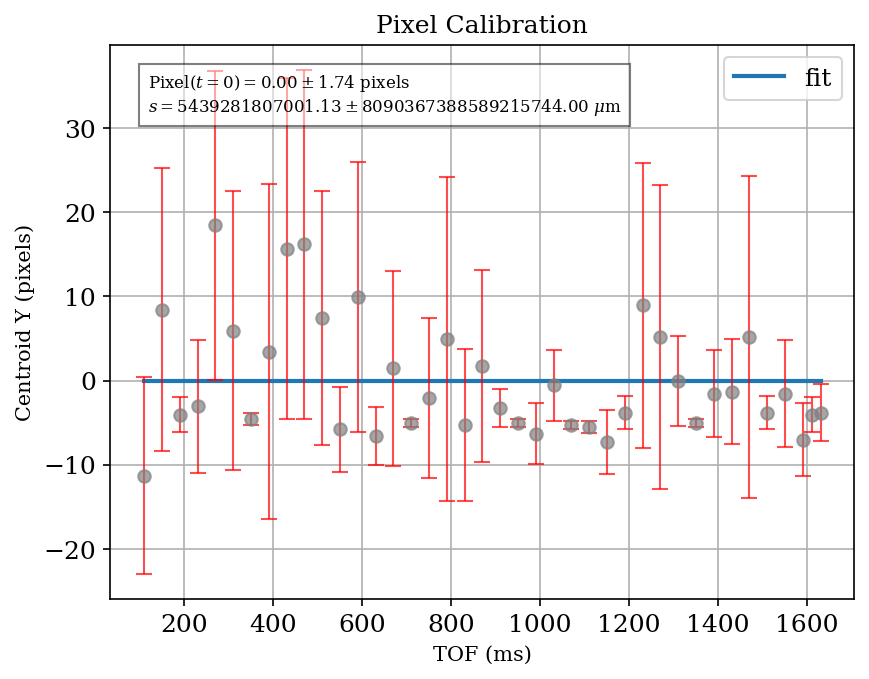

In [105]:
# pixel calibration fit
g = 9.81  # m/s^2, gravitational acceleration

peakx_mean=mean_std(Peak_x_set)[0]
peakx_std=mean_std(Peak_x_set)[1]

try:
    t_data = Scan_params_set[0]  # TOF data, assuming all sets have the same scan parameters
except IndexError:
    print("Error: Scan_params_set is empty. Please check the data extraction process.")
    t_data = []

pixel_number_vertical_data = np.array(peakx_mean)  # Pixel data, using peakx as an example
print("Pixel data:", pixel_number_vertical_data)

print("TOF data:", t_data)


# increasing order t data
t_data_sorted = np.sort(t_data)
print("Sorted TOF data:", t_data_sorted)


# return index of some value in t_data_sorted
def get_index_of_value(value, t_data_sorted):
    try:
        return np.where(t_data_sorted == value)[0][0]
    except IndexError:
        return -1


# pixel data sorted
pixel_data_sorted = pixel_number_vertical_data[np.argsort(t_data)]
print("Sorted Pixel data:", pixel_data_sorted)

pixel_data_sorted = -(pixel_data_sorted - np.mean(pixel_data_sorted))


def model_pixel_calibration(t, y0, s):
    return y0 + (1 / 2) * t**2 * g / s


# Initial GUESS
y0_initial = 0.0
s_initial = 40e-6



# Fit your existing data
popt_pixel, pcov_pixel = curve_fit(
    model_pixel_calibration,
    t_data_sorted,
    pixel_data_sorted,
    p0=[y0_initial, s_initial],
)
y0_fit = popt_pixel[0]
y0_err = np.sqrt(np.diag(pcov_pixel))[0]
s_fit = popt_pixel[1]
s_err = np.sqrt(np.diag(pcov_pixel))[1]

# Print results
print(f"y0 = {y0_fit:.7f} ± {y0_err:.7f} pixels")
print(f"s = {s_fit * 1e6:.7f} ± {s_err * 1e6:.7f} μm")


# Plot pixel calibration
#plt.plot(t_data_sorted * 1e3, pixel_data_sorted, "o", label="data")
plt.plot(
    t_data_sorted * 1e3,
    model_pixel_calibration(t_data_sorted, *popt_pixel),
    label="fit",
)
#make the point size transparent

plt.xlabel("TOF (ms)", fontdict={"fontsize": 10, "family": "serif"})
plt.ylabel("Centroid Y (pixels)", fontdict={"fontsize": 10, "family": "serif"})
plt.legend()
plt.grid(True)

fit_text = (
    r"$\mathrm{Pixel}(t=0) = "
    + f"{y0_fit:.2f} \pm {y0_err:.2f}"
    + r"\ \mathrm{{pixels}}$"
    + "\n"
    + r"$s = "
    + f"{s_fit * 1e6:.2f} \pm {s_err * 1e6:.2f}"
    + r"\ \mu\mathrm{m}$"
)

plt.gca().text(
    0.05,
    0.95,
    fit_text,
    transform=plt.gca().transAxes,
    verticalalignment="top",
    bbox=dict(facecolor="white", alpha=0.5, edgecolor="black"),
    fontdict={"fontsize": 8, "family": "serif"}
)

plt.errorbar(
    t_data_sorted * 1e3,
    pixel_data_sorted,
    yerr=peakx_std,
    fmt="o",
    color="gray",
    ecolor="red",
    elinewidth=1,
    capsize=4, alpha=0.7
)

#plt.tight_layout()
plt.title("Pixel Calibration", fontdict={"fontsize": 12, "family": "serif"})
plt.show()

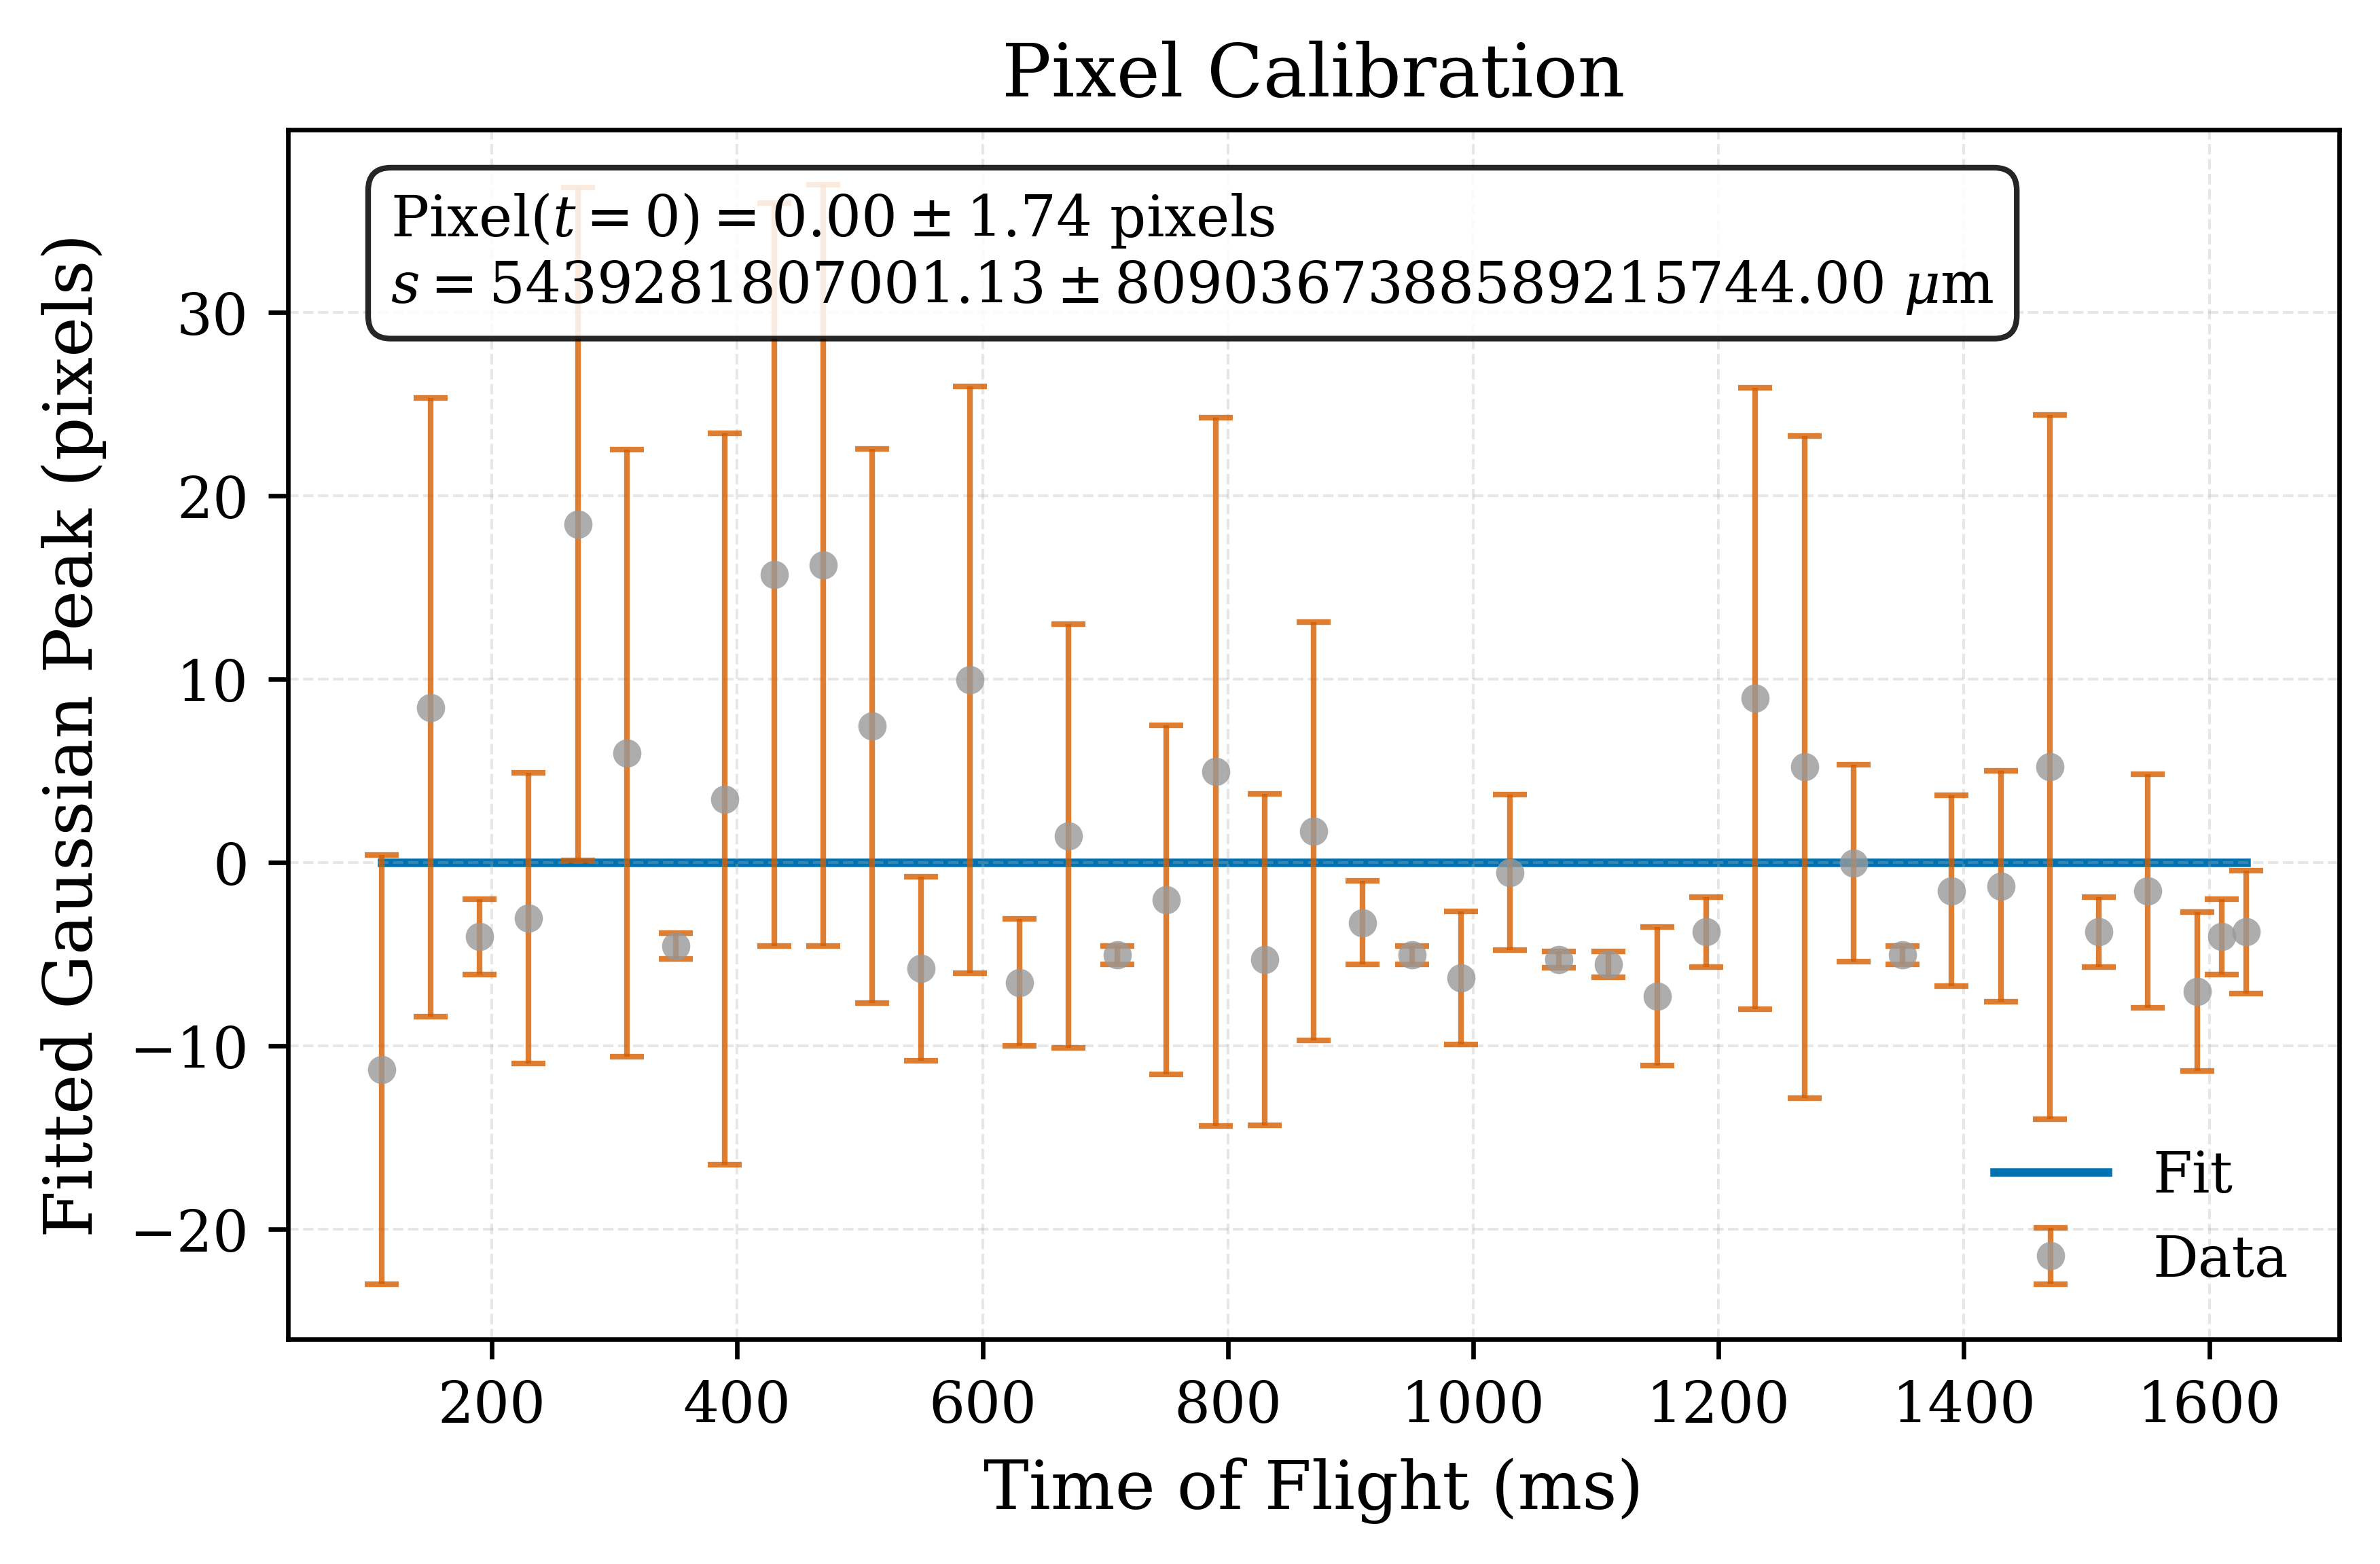

In [106]:
import matplotlib.pyplot as plt

# Global style settings (without LaTeX)
plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "dejavuserif",  # serif math font
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "lines.linewidth": 1.5,
        "errorbar.capsize": 3,
    }
)

# Create high-resolution figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=600)

# --- Fit Line ---
ax.plot(
    t_data_sorted * 1e3,
    model_pixel_calibration(t_data_sorted, *popt_pixel),
    color="#0072B2",  # Blue
    label="Fit",
    zorder=1,
)

# --- Data Points with Error Bars ---
ax.errorbar(
    t_data_sorted * 1e3,
    pixel_data_sorted,
    yerr=peakx_std,
    fmt="o",
    color="#999999",  # Light gray points
    ecolor="#D55E00",  # Reddish error bars
    markerfacecolor="#999999",
    markeredgecolor="none",
    alpha=0.8,
    markersize=5,
    linewidth=1,
    zorder=2,
    label="Data",
)

# --- Fit Text Annotation (Mathtext only) ---
fit_text = (
    r"$\mathrm{Pixel}(t{=}0) = "
    + f"{y0_fit:.2f} \pm {y0_err:.2f}"
    + r"\ \mathrm{pixels}$"
    + "\n"
    + r"$s = "
    + f"{s_fit * 1e6:.2f} \pm {s_err * 1e6:.2f}"
    + r"\ \mu\mathrm{m}$"
)

ax.text(
    0.05,
    0.95,
    fit_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        facecolor="white", edgecolor="black", boxstyle="round,pad=0.4", alpha=0.85
    ),
)

# --- Labels and Title ---
ax.set_xlabel("Time of Flight (ms)")
ax.set_ylabel("Fitted Gaussian Peak (pixels)")
ax.set_title("Pixel Calibration")

# --- Styling ---
ax.grid(True, linestyle="--", linewidth=0.5, alpha=0.3)
ax.legend(frameon=False, loc="best")
plt.tight_layout()

# --- Show or Save ---
# plt.savefig("pixel_calibration.png", dpi=600, bbox_inches='tight')
plt.show()


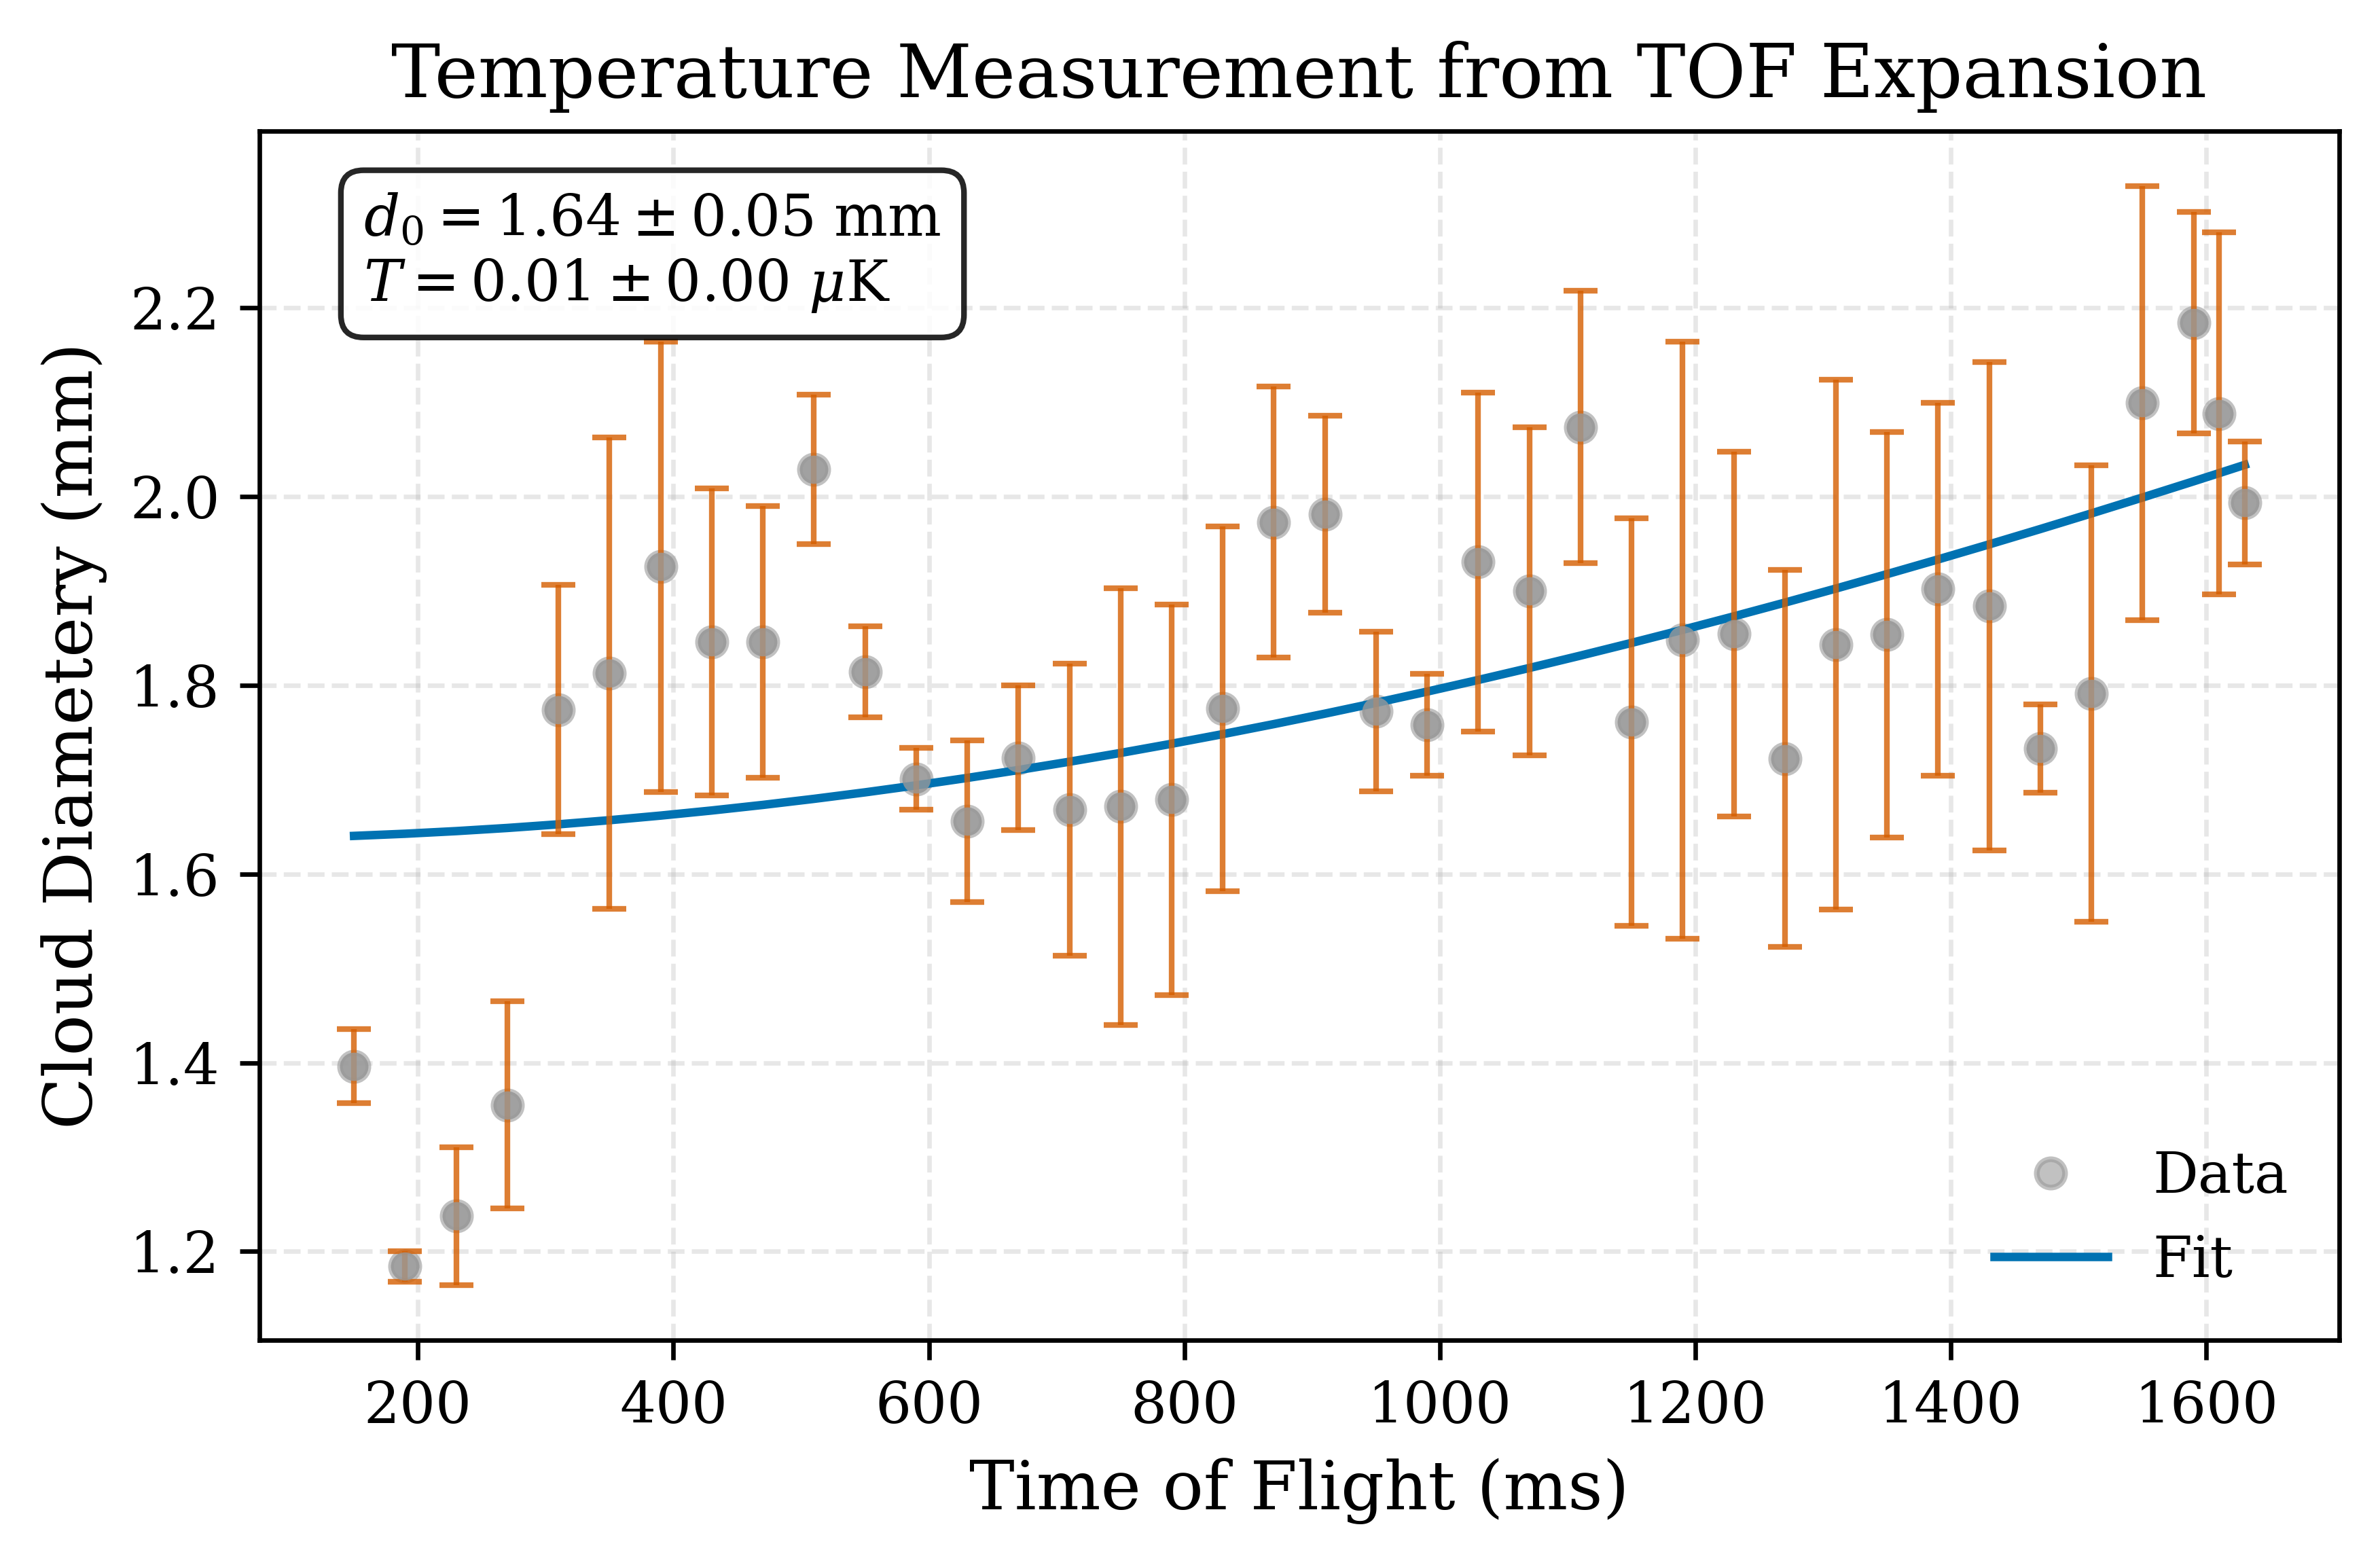

d₀ = 1.6366 ± 0.0491 mm
T  = 0.0058 ± 0.0016 μK
Final temperature: 0.0058 ± 0.0046 μK


In [107]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# ----------------------------
# Data (replace with yours)
# ----------------------------


diameter_data = Sy_set  # Measured diameters (pixels)

sy_mean = mean_std(diameter_data)[0]
sy_std = mean_std(diameter_data)[1]

physical_scale=24.83e-6  # µm/pixel from pixel calibration
sy_mean = [i * physical_scale for i in sy_mean]  # Convert to meters
sy_std = [i * physical_scale for i in sy_std]  # Convert to meters

d_data = np.array(sy_mean)  # Measured diameters (m)

# Sort data
t_data_sorted = np.sort(t_data)
d_data_sorted = d_data[np.argsort(t_data)]

#remove the first data point (optional)
t_data_sorted = t_data_sorted[1:]
d_data_sorted = d_data_sorted[1:]
sy_mean = sy_mean[1:]
sy_std = sy_std[1:]

# ----------------------------
# ⚙️ Physics constants
# ----------------------------
kB = 1.380649e-23  # J/K
m = 1.45e-25  # Mass of atom (kg)


# ----------------------------
# Model: d(t) = sqrt(d0^2 + (kB*T/m)*t^2)
# ----------------------------
def model(t, d0, T):
    return np.sqrt(d0**2 + (kB * T * t**2) / m)


# Fit parameters
p0 = [2e-3, 100e-6]  # Initial guess: [d0 (m), T (K)]
bounds = ([0, 0], [np.inf, np.inf])
popt, pcov = curve_fit(model, t_data_sorted, d_data_sorted, p0=p0, bounds=bounds)

d0_fit, T_fit = popt
d0_err, T_err = np.sqrt(np.diag(pcov))

# ----------------------------
# 🎨 Plotting (Nature style)
# ----------------------------

# Plot style
plt.rcParams.update(
    {
        "font.family": "serif",
        "mathtext.fontset": "dejavuserif",
        "axes.labelsize": 12,
        "axes.titlesize": 13,
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
        "legend.fontsize": 10,
        "lines.linewidth": 1.5,
        "errorbar.capsize": 3,
    }
)

# Create figure
fig, ax = plt.subplots(figsize=(6, 4), dpi=600)

# --- Data Points ---
ax.plot(
    t_data_sorted * 1e3,
    d_data_sorted * 1e3,
    "o",
    color="#999999",
    markersize=5,
    alpha=0.6,
    label="Data",
)

# --- Fit Curve ---
ax.plot(
    t_data_sorted * 1e3, model(t_data_sorted, *popt) * 1e3, color="#0072B2", label="Fit"
)

# --- Fit Parameters Box ---
fit_text = (
    r"$d_0 = "
    + f"{d0_fit * 1e3:.2f} \pm {d0_err * 1e3:.2f}"
    + r"\ \mathrm{{mm}}$"
    + "\n"
    + r"$T = "
    + f"{T_fit * 1e6:.2f} \pm {T_err * 1e6:.2f}"
    + r"\ \mu\mathrm{{K}}$"
)

ax.text(
    0.05,
    0.95,
    fit_text,
    transform=ax.transAxes,
    fontsize=10,
    verticalalignment="top",
    bbox=dict(
        facecolor="white", edgecolor="black", boxstyle="round,pad=0.4", alpha=0.85
    ),
)

# --- Labels & Layout ---
ax.set_xlabel("Time of Flight (ms)")
ax.set_ylabel("Cloud Diametery (mm)")
ax.set_title("Temperature Measurement from TOF Expansion")
ax.grid(True, linestyle="--", alpha=0.3)
ax.legend(frameon=False)
plt.tight_layout()


#multiply each element of sy_mean and sy_std with 1e3 to convert to mm
sy_mean = [i * 1e3 for i in sy_mean]
sy_std = [i * 1e3 for i in sy_std]

#error bars
ax.errorbar(
    t_data_sorted * 1e3,
    sy_mean,
    yerr=sy_std,
    fmt="o",
    color="#999999",  # Light gray points
    ecolor="#D55E00",  # Reddish error bars
    markerfacecolor="#999999",
    markeredgecolor="none",
    alpha=0.8,
    markersize=5,
    linewidth=1,
    zorder=2,
    label="Data",
)
plt.show()
# ----------------------------
# Final Output
# ----------------------------

print(f"d₀ = {d0_fit * 1e3:.4f} ± {d0_err * 1e3:.4f} mm")
print(f"T  = {T_fit * 1e6:.4f} ± {T_err * 1e6:.4f} μK")

# Pixel size calibration uncertainty
s = 28.19  # µm/pixel
delta_s = 10.59  # µm/pixel

delta_T_pixel = T_fit * 2 * (delta_s / s)
delta_T_total = np.sqrt(T_err**2 + delta_T_pixel**2)

print(f"Final temperature: {T_fit * 1e6:.4f} ± {delta_T_total * 1e6:.4f} μK")



In [108]:
from scipy import constants as const


sigma_x = 0.36e-3  # in meters
#sigma_y = 0.36e-3  # in meters
sigma_z = 0.68e-3  # in meters
T = 30e-6  # in Kelvin
m = 1.443e-25  # in kg
Atom_number = 4e6  # Total number of atoms

def phase_space_density(self, sigma_x,sigma_z,T,m):
    """
    Calculate phase-space density for a thermal atomic cloud.

    Parameters
    ----------
    N : float
        Total number of atoms in the cloud.
    sigma_x, sigma_y, sigma_z : floats
        Position-space 1/e standard deviations (meters) along x, y, z.
    T : float
        Temperature in Kelvin.
    m : float
        Mass of one atom in kilograms.

    Returns
    -------
    n : float
        Number density (atoms per cubic meter).
    lambda_db : float
        Thermal de Broglie wavelength (meters).
    PSD : float
        Phase-space density (dimensionless, N λ³ / V).
    """


    # Volume of the cloud assuming Gaussian distribution, 3D
    # V = (2π)^(3/2) σx σy σz
    V = (2 * np.pi) ** (3 / 2) * sigma_x * sigma_x * sigma_z

    # Number density
    n = Atom_number / V

    # Thermal de Broglie wavelength
    # λ_dB = h / sqrt(2 π m k_B T)
    lambda_db = const.h / np.sqrt(2 * np.pi * m * const.k * T)

    # Phase-space density: n * λ_dB^3
    PSD = n * lambda_db**3

    return n, lambda_db, PSD

n, lambda_db, PSD = phase_space_density(sigma_x, sigma_x, sigma_z, T, m)
print(f"Number density: {n:.2e} atoms/m³")
print(f"Thermal de Broglie wavelength: {lambda_db:.2e} m")
print(f"Phase-space density: {PSD:.2e}")


Number density: 2.88e+15 atoms/m³
Thermal de Broglie wavelength: 3.42e-08 m
Phase-space density: 1.15e-07
